In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [5]:
PROJECT_ROOT = Path.cwd().parents[1]

METADATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "metadata"
    / "metadata.csv"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("METADATA_PATH:", METADATA_PATH)
print("PROCESSED_DIR:", PROCESSED_DIR)

PROJECT_ROOT: d:\AI\projects\project_02_signature_verification_structure\project_02_signature_verification
METADATA_PATH: d:\AI\projects\project_02_signature_verification_structure\project_02_signature_verification\data\metadata\metadata.csv
PROCESSED_DIR: d:\AI\projects\project_02_signature_verification_structure\project_02_signature_verification\data\processed


In [6]:
metadata_df = pd.read_csv(METADATA_PATH)

metadata_df.head()

,file_path,file_name,writer_id,signature_type,is_genuine
0,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,1.tif,1,genuine,1
1,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,10.tif,1,genuine,1
2,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,11.tif,1,genuine,1
3,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,12.tif,1,genuine,1
4,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,13.tif,1,genuine,1


In [7]:
print("Rows :" , len(metadata_df))

print(metadata_df["signature_type"].value_counts())

Rows : 7934
signature_type
simple_forgery     4140
genuine            3105
skilled_forgery     689
Name: count, dtype: int64


In [8]:
sample_row = metadata_df.sample(
  1 , random_state = 42
).iloc[0]

sample_path = (
  PROJECT_ROOT / sample_row["file_path"]
)

img = cv2.imread(str(sample_path) , cv2.IMREAD_GRAYSCALE)

print("path :" , sample_path)
print("shape :" , img.shape)

path : d:\AI\projects\project_02_signature_verification_structure\project_02_signature_verification\data\raw\utsig\UTSig_FullSize\UTSig_FullSize\Genuine\34\2.tif
shape : (1055, 1518)


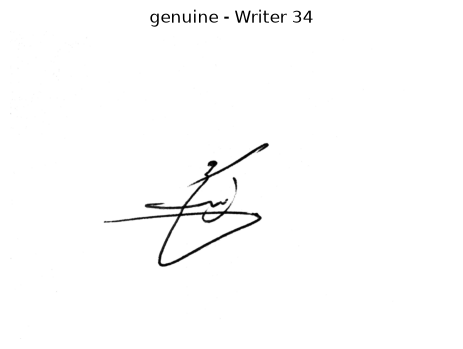

In [9]:
plt.figure(figsize=(8 , 4))

plt.imshow(img , cmap="gray")

plt.title(f'{sample_row["signature_type"]} - Writer {sample_row["writer_id"]}')

plt.axis("off")

plt.show()

In [10]:
_, binary_img = cv2.threshold(
    img,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

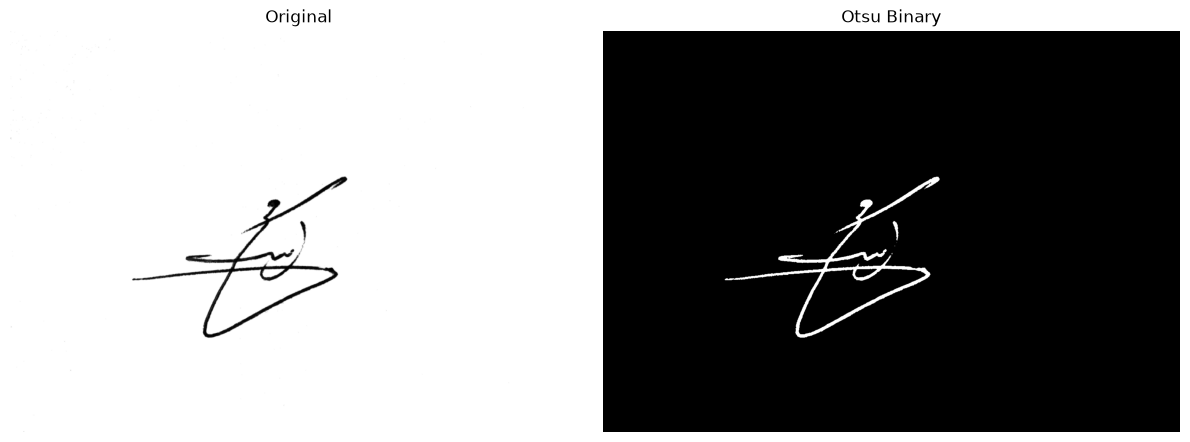

In [11]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

axes[0].imshow(
    img,
    cmap="gray"
)

axes[0].set_title(
    "Original"
)

axes[0].axis("off")


axes[1].imshow(
    binary_img,
    cmap="gray"
)

axes[1].set_title(
    "Otsu Binary"
)

axes[1].axis("off")

plt.tight_layout()
plt.show()

In [12]:
coords = cv2.findNonZero(
  binary_img
)

x,y,w,h = cv2.boundingRect(
  coords
)

print("x :" , x)
print("y :" , y)
print("width :" , w)
print("height :" , h)

x : 321
y : 384
width : 565
height : 423


In [13]:
cropped = img[
    y:y+h,
    x:x+w
]

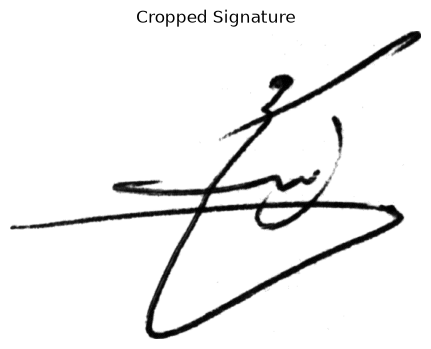

In [14]:
plt.figure(figsize=(8, 4))

plt.imshow(
    cropped,
    cmap="gray"
)

plt.title(
    "Cropped Signature"
)

plt.axis("off")

plt.show()

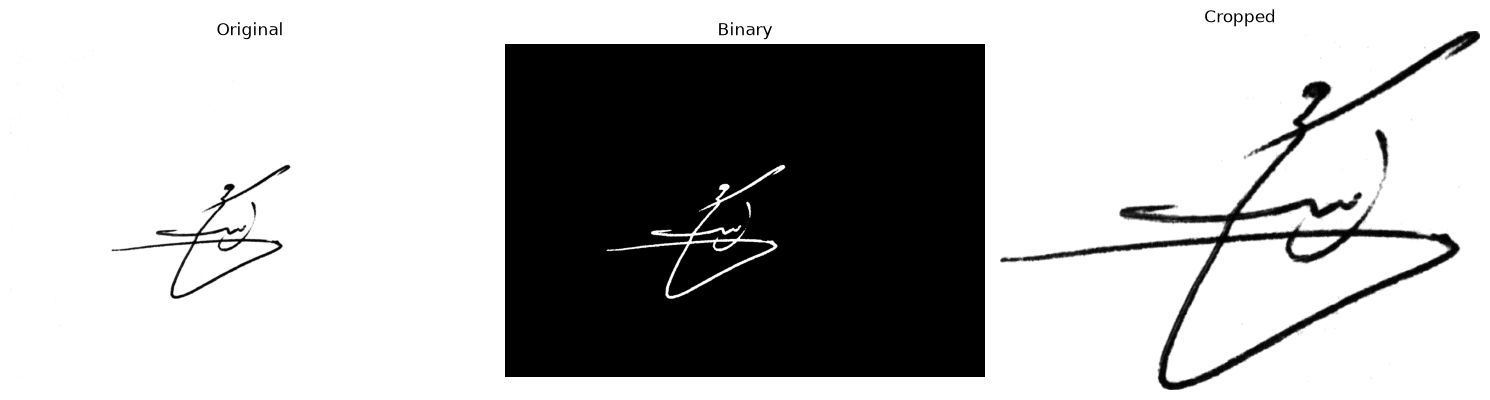

In [15]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    img,
    cmap="gray"
)
axes[0].set_title("Original")
axes[0].axis("off")


axes[1].imshow(
    binary_img,
    cmap="gray"
)
axes[1].set_title("Binary")
axes[1].axis("off")


axes[2].imshow(
    cropped,
    cmap="gray"
)
axes[2].set_title("Cropped")
axes[2].axis("off")


plt.tight_layout()
plt.show()

In [16]:
def resize_with_padding(
  image, target_width = 256,target_height = 128 , background_color = 255
):
  
  height , width =image.shape
  
  scale = min(target_width / width , target_height / height)
  
  
  new_width = int(width * scale)
  new_height = int(height * scale)
  

  
  resized = cv2.resize(
    image , (new_width , new_height), interpolation = cv2.INTER_AREA
  )
  
  
  canvas = np.full(
    (target_height , target_width),
    background_color , 
    dtype = np.uint8
  )
  
  x_offset = (
    target_width - new_width
  ) // 2
  

  y_offset = (
    target_height - new_height
  ) // 2
  
  
  canvas[
    y_offset:y_offset + new_height,
    x_offset:x_offset + new_width
  ] = resized

  return canvas
    

In [17]:
final_image = resize_with_padding(
  cropped , target_width = 256 , target_height = 128
)

print(final_image.shape)

(128, 256)


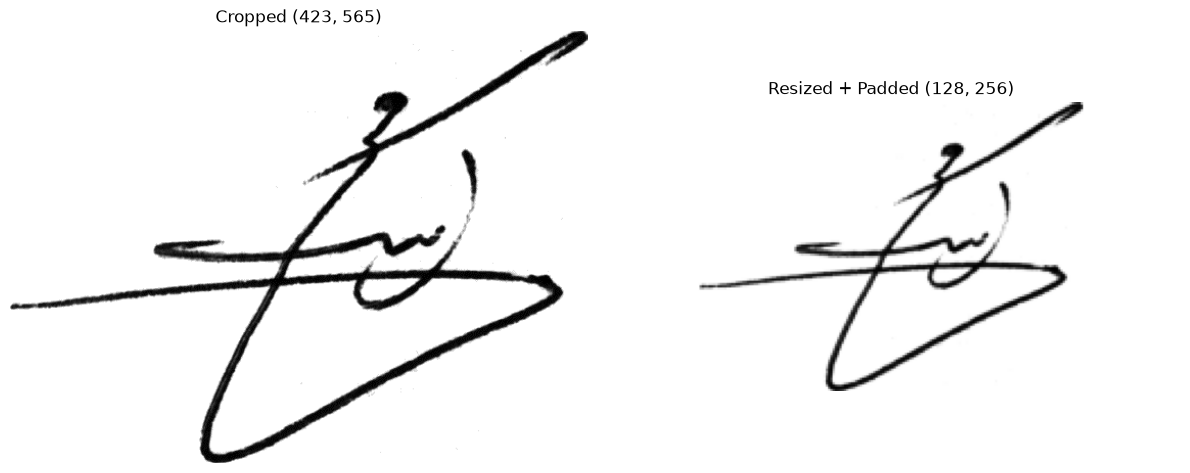

In [18]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

axes[0].imshow(
    cropped,
    cmap="gray"
)

axes[0].set_title(
    f"Cropped {cropped.shape}"
)

axes[0].axis("off")


axes[1].imshow(
    final_image,
    cmap="gray"
)

axes[1].set_title(
    f"Resized + Padded {final_image.shape}"
)

axes[1].axis("off")

plt.tight_layout()
plt.show()

In [19]:
def preprocess_signature(
    image_path,
    target_width=256,
    target_height=128
):
    # 1) Read grayscale
    img = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        return None

    # 2) Threshold
    _, binary_img = cv2.threshold(
        img,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # 3) Find signature pixels
    coords = cv2.findNonZero(
        binary_img
    )

    # اگر تصویر خالی بود
    if coords is None:
        return None

    # 4) Bounding box
    x, y, w, h = cv2.boundingRect(
        coords
    )

    # 5) Crop
    cropped = img[
        y:y+h,
        x:x+w
    ]

    # 6) Preserve aspect ratio
    height, width = cropped.shape

    scale = min(
        target_width / width,
        target_height / height
    )

    new_width = max(
        1,
        int(width * scale)
    )

    new_height = max(
        1,
        int(height * scale)
    )

    # 7) Resize
    resized = cv2.resize(
        cropped,
        (
            new_width,
            new_height
        ),
        interpolation=cv2.INTER_AREA
    )

    # 8) White canvas
    canvas = np.full(
        (
            target_height,
            target_width
        ),
        255,
        dtype=np.uint8
    )

    # 9) Center image
    x_offset = (
        target_width
        - new_width
    ) // 2

    y_offset = (
        target_height
        - new_height
    ) // 2

    canvas[
        y_offset:y_offset + new_height,
        x_offset:x_offset + new_width
    ] = resized

    return canvas

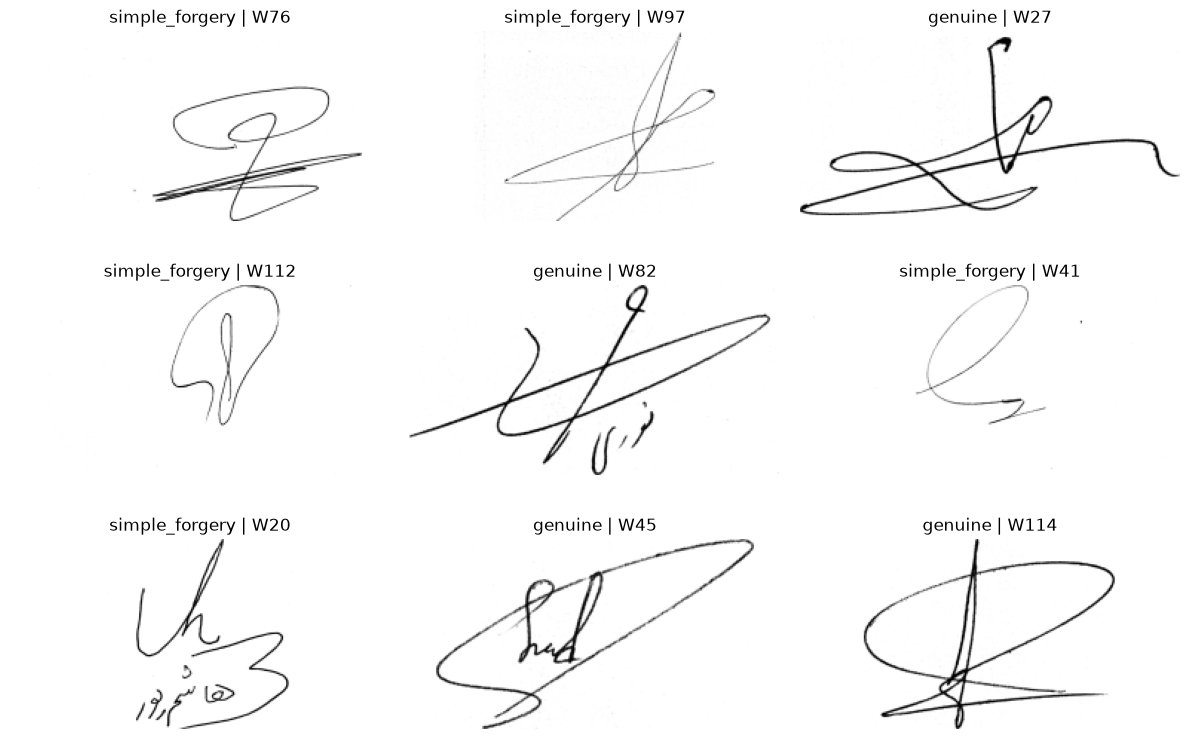

In [20]:
samples = metadata_df.sample(
    9,
    random_state=123
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 8)
)

for ax, (_, row) in zip(
    axes.flat,
    samples.iterrows()
):
    image_path = (
        PROJECT_ROOT
        / row["file_path"]
    )

    processed = preprocess_signature(
        image_path
    )

    ax.imshow(
        processed,
        cmap="gray"
    )

    ax.set_title(
        f'{row["signature_type"]} | W{row["writer_id"]}'
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
!pip install tqdm

In [24]:
from tqdm import tqdm

In [25]:
PROCESSED_ROOT = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

PROCESSED_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

In [26]:
def get_processed_path(row):
    
    signature_type = row["signature_type"]
    writer_id = str(row["writer_id"])

    output_dir = (
        PROCESSED_ROOT
        / signature_type
        / writer_id
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    output_path = (
        output_dir
        / row["file_name"]
    )

    return output_path

In [27]:
processed_paths = []
failed_images = []

for _, row in tqdm(
    metadata_df.iterrows(),
    total=len(metadata_df)
):

    input_path = (
        PROJECT_ROOT
        / row["file_path"]
    )

    processed = preprocess_signature(
        input_path
    )

    if processed is None:
        failed_images.append(
            row["file_path"]
        )

        processed_paths.append(
            None
        )

        continue

    output_path = get_processed_path(
        row
    )

    success = cv2.imwrite(
        str(output_path),
        processed
    )

    if not success:
        failed_images.append(
            row["file_path"]
        )

        processed_paths.append(
            None
        )

        continue

    processed_paths.append(
        str(
            output_path.relative_to(
                PROJECT_ROOT
            )
        )
    )

100%|██████████| 7934/7934 [02:40<00:00, 49.41it/s]


In [28]:
print(
    "Processed:",
    len(processed_paths)
)

print(
    "Failed:",
    len(failed_images)
)

Processed: 7934
Failed: 0


In [29]:
metadata_df[
    "processed_path"
] = processed_paths

In [30]:
metadata_df.head()

,file_path,file_name,writer_id,signature_type,is_genuine,processed_path
0,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,1.tif,1,genuine,1,data\processed\genuine\1\1.tif
1,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,10.tif,1,genuine,1,data\processed\genuine\1\10.tif
2,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,11.tif,1,genuine,1,data\processed\genuine\1\11.tif
3,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,12.tif,1,genuine,1,data\processed\genuine\1\12.tif
4,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,13.tif,1,genuine,1,data\processed\genuine\1\13.tif


In [31]:
metadata_df.to_csv(
    METADATA_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Updated metadata saved to:",
    METADATA_PATH
)

Updated metadata saved to: d:\AI\projects\project_02_signature_verification_structure\project_02_signature_verification\data\metadata\metadata.csv


In [32]:
print(
    metadata_df["processed_path"]
    .isna()
    .sum()
)

0


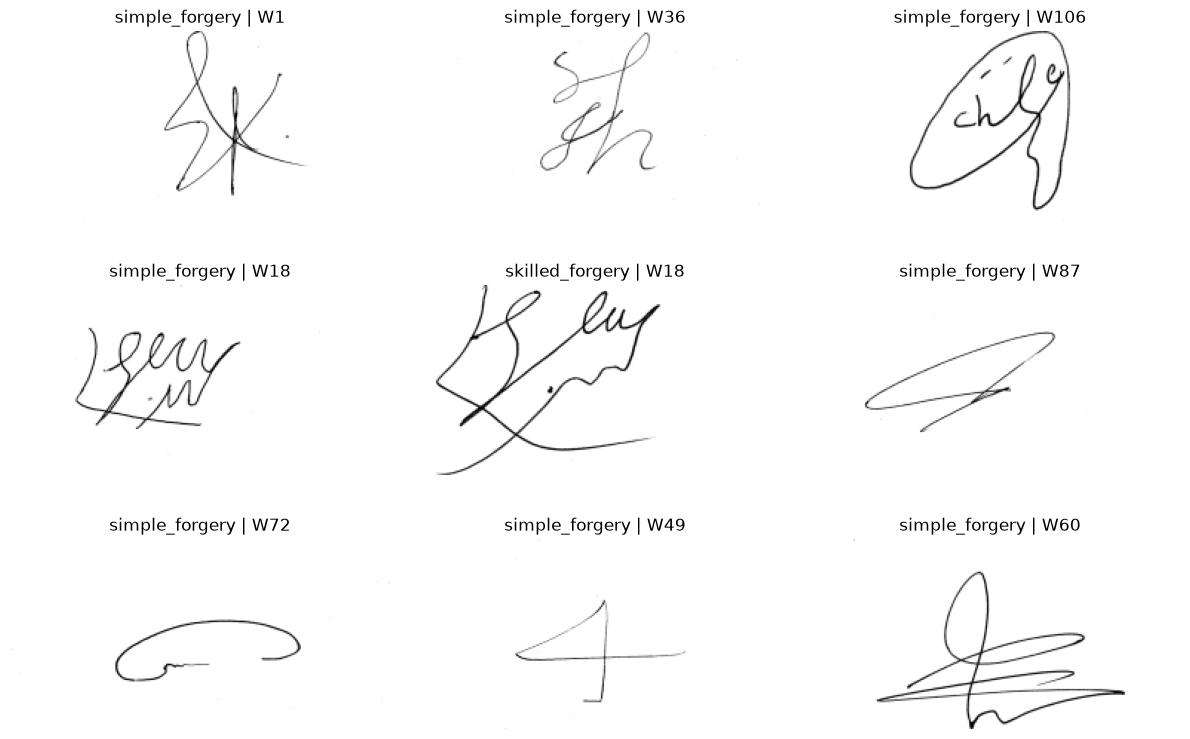

In [33]:
samples = metadata_df.sample(
    9,
    random_state=55
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 8)
)

for ax, (_, row) in zip(
    axes.flat,
    samples.iterrows()
):

    img = cv2.imread(
        str(
            PROJECT_ROOT
            / row["processed_path"]
        ),
        cv2.IMREAD_GRAYSCALE
    )

    ax.imshow(
        img,
        cmap="gray"
    )

    ax.set_title(
        f'{row["signature_type"]} | W{row["writer_id"]}'
    )

    ax.axis("off")

plt.tight_layout()
plt.show()